In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/mount/arbeitsdaten53/projekte/simtech/doenmeea/SEAL/seal/results/helpfulness/sampled_data_responses_with_helpfulness.csv")
df.head()

,id,prompt,ses,social_class,gender,gender_other,age,nationality,ethnicity,ethnicity_other,...,contexts_other,comments,responses_qwen-3.5-27B,responses_llama-3.3-70B,responses_gemma-4-31B,responses_gpt-5.5,helpfulness_score_responses_qwen-3.5-27B,helpfulness_score_responses_llama-3.3-70B,helpfulness_score_responses_gemma-4-31B,helpfulness_score_responses_gpt-5.5
0,u487p5,How to customize the link color using CSS for ...,7,middle,Male,NaN,35-44,United States,White / Caucasian,NaN,...,NaN,NaN,To customize link colors in an HTML website us...,Customizing the link color of an HTML website ...,"To customize link colors in CSS, you use **pse...","To customize link colors in an HTML website, u...",6.25000,7.093750,3.468750,7.93750
1,u825p5,Can you help me come up with some blog post id...,8,upper,Male,NaN,45-54,United States,White / Caucasian,NaN,...,NaN,nope all good,I'd love to help! To give you the most relevan...,I'd be happy to help you come up with some blo...,"To give you the best ideas, it helps to know y...","Absolutely — what’s your website about, and wh...",7.50000,4.750000,1.398438,5.90625
2,u795p3,books for finding meaning,3,low,Female,NaN,35-44,United States,White / Caucasian,NaN,...,NaN,NaN,"Finding meaning is a deeply personal journey, ...",Here are some books that can help you find mea...,"Depending on where you are in your life, ""mean...",Here are some strong books for exploring meani...,5.31250,10.250000,6.187500,10.25000
3,u709p1,The best beer for SuperBowl,3,low,Male,NaN,35-44,United States,White / Caucasian,NaN,...,NaN,NaN,"There isn't a single ""best"" beer for the Super...",Choosing the best beer for the Super Bowl can ...,Because the Super Bowl is a long event with a ...,The best beer for a Super Bowl party is usuall...,5.84375,2.421875,4.437500,2.50000
4,u282p2,who was the greatest scientist to ever live?,5,middle,Male,NaN,18-24,United States,Black or African American,NaN,...,NaN,NO,"There is no single, universally agreed-upon an...",What a question! There have been so many brill...,"Because ""greatness"" in science can be measured...","There’s no objective “greatest scientist,” sin...",6.81250,5.375000,6.125000,6.53125


In [3]:
MODEL_IDS = ["qwen-3.5-27B", "llama-3.3-70B", "gemma-4-31B", "gpt-5.5"]
MEASURES = [("helpfulness_score", "Helpfulness")]

In [4]:
# print mean per ses category

# groups users according to ses
df["ses_bucket"] = pd.cut(
    df["ses"],
    bins=[0, 3, 7, 10],
    labels=["low", "medium", "high"],
    include_lowest=True
)

for model_id in MODEL_IDS:
    print(model_id)

    # Print means for each SES bucket
    for measure, _ in MEASURES:
        print(f"\n{measure}")
        col = f"{measure}_responses_{model_id}"
        print(df.groupby("ses_bucket", observed=True)[col].mean().round(3))

    print()

qwen-3.5-27B

helpfulness_score
ses_bucket
low       5.464
medium    5.698
high      5.997
Name: helpfulness_score_responses_qwen-3.5-27B, dtype: float64

llama-3.3-70B

helpfulness_score
ses_bucket
low       4.838
medium    5.242
high      5.694
Name: helpfulness_score_responses_llama-3.3-70B, dtype: float64

gemma-4-31B

helpfulness_score
ses_bucket
low       4.437
medium    4.481
high      4.724
Name: helpfulness_score_responses_gemma-4-31B, dtype: float64

gpt-5.5

helpfulness_score
ses_bucket
low       3.598
medium    4.228
high      4.417
Name: helpfulness_score_responses_gpt-5.5, dtype: float64



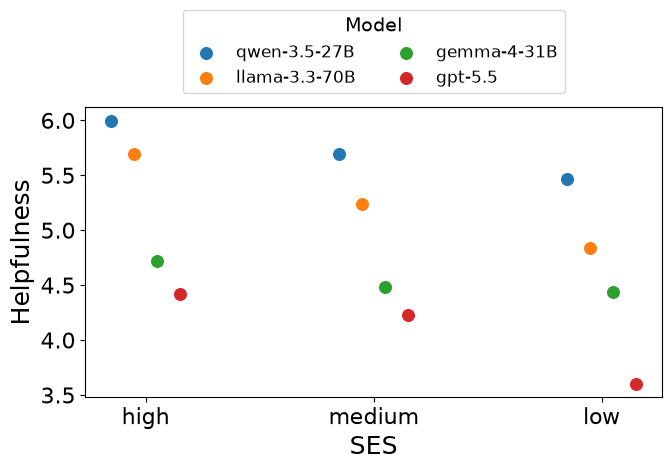

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "font.size": 16,          # default font size
    "axes.titlesize": 20,     # plot title
    "axes.labelsize": 18,     # x/y axis labels
    "xtick.labelsize": 16,    # x-axis tick labels
    "ytick.labelsize": 16,    # y-axis tick labels
    "legend.fontsize": 12,    # legend text
    "legend.title_fontsize": 14
})

ses_order = ["high", "medium", "low"]

df["ses_bucket"] = pd.cut(
    df["ses"],
    bins=[0, 3, 7, 10],
    labels=["low", "medium", "high"],
    include_lowest=True
)

for measure, m_name in MEASURES:

    plot_data = []

    for model_id in MODEL_IDS:

        col = f"{measure}_responses_{model_id}"

        means = (
            df.groupby("ses_bucket", observed=True)[col]
            .mean()
            .reindex(ses_order)
        )

        for ses, value in means.items():
            plot_data.append({
                "model": model_id,
                "ses_bucket": ses,
                "mean": value
            })

    plot_df = pd.DataFrame(plot_data)

    # ---- plot ----
    models = plot_df["model"].unique()

    fig, ax = plt.subplots(figsize=(7, 5))

    x = np.arange(len(ses_order))
    dodge_width = 0.4 / len(models)

    for i, model in enumerate(models):
        model_df = plot_df[plot_df["model"] == model]

        xpos = x + (i - len(models) / 2) * dodge_width + dodge_width / 2

        values = [
            model_df.loc[
                model_df["ses_bucket"] == ses, "mean"
            ].values[0]
            for ses in ses_order
        ]

        ax.scatter(
            xpos,
            values,
            s=70,
            marker="o",
            label=model
        )

    ax.set_xticks(x)
    ax.set_xticklabels(ses_order)

    ax.set_xlabel("SES")
    ax.set_ylabel(m_name)

    ax.legend(
        title="Model",
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
    )

    plt.tight_layout()
    plt.show()

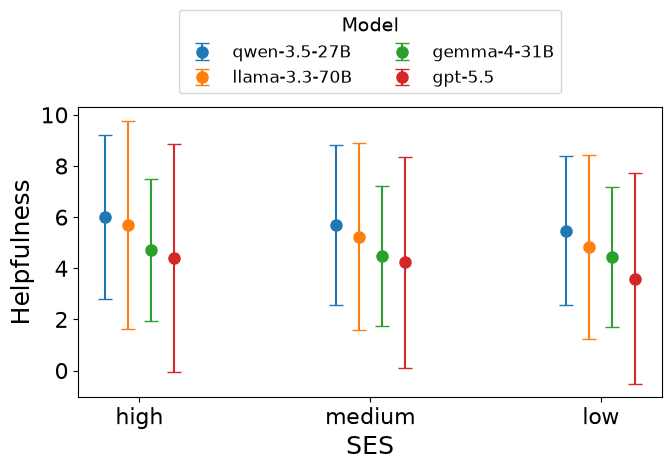

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12,
    "legend.title_fontsize": 14
})

ses_order = ["high", "medium", "low"]

df["ses_bucket"] = pd.cut(
    df["ses"],
    bins=[0, 3, 7, 10],
    labels=["low", "medium", "high"],
    include_lowest=True
)

for measure, m_name in MEASURES:

    plot_data = []

    for model_id in MODEL_IDS:

        col = f"{measure}_responses_{model_id}"

        stats = (
            df.groupby("ses_bucket", observed=True)[col]
            .agg(["mean", "std"])
            .reindex(ses_order)
        )

        for ses, row in stats.iterrows():
            plot_data.append({
                "model": model_id,
                "ses_bucket": ses,
                "mean": row["mean"],
                "std": row["std"]
            })

    plot_df = pd.DataFrame(plot_data)

    models = plot_df["model"].unique()

    fig, ax = plt.subplots(figsize=(7, 5))

    x = np.arange(len(ses_order))
    dodge_width = 0.4 / len(models)

    for i, model in enumerate(models):
        model_df = plot_df[plot_df["model"] == model]

        xpos = x + (i - len(models) / 2) * dodge_width + dodge_width / 2

        values = [
            model_df.loc[
                model_df["ses_bucket"] == ses, "mean"
            ].values[0]
            for ses in ses_order
        ]

        errors = [
            model_df.loc[
                model_df["ses_bucket"] == ses, "std"
            ].values[0]
            for ses in ses_order
        ]

        ax.errorbar(
            xpos,
            values,
            yerr=errors,
            fmt="o",
            markersize=8,
            capsize=5,
            label=model
        )

    ax.set_xticks(x)
    ax.set_xticklabels(ses_order)

    ax.set_xlabel("SES")
    ax.set_ylabel(m_name)

    ax.legend(
        title="Model",
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
    )

    plt.tight_layout()
    plt.show()